In [1]:
# Sensitivity test for number of samples in parametric bootstrapping

In [2]:
import os
import xarray as xr
import numpy as np
import warnings
import matplotlib.pyplot as plt
from utils.utils import get_scenario_config
from utils.mortality_utils import att_frac

In [3]:
# === Path config ===
MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
BMR_DIR = "/glade/derecho/scratch/awells/air_quality/BMR/"

In [4]:
# Load country masks
mask_file = "GBD_Country_Masks_0.10.nc"
mask_path = os.path.join(MASKS_DIR, mask_file)
masks = xr.open_dataarray(mask_path)

# Load population file
pop_file = "ssp2_coarse_grid_annual_2000-2100.nc"
pop_path = os.path.join(POP_DIR, pop_file)
population = xr.open_dataarray(pop_path)
pop = population.reindex_like(masks, method="nearest", tolerance=1e-9)

In [8]:
# === Calculate the scalar distributions ===
n_samples = 200

# TMREL from GBD21 (uniform distribution)
tmrel_low = 29.1
tmrel_high = 35.7
tmrel_samples = np.random.uniform(tmrel_low, tmrel_high, size=n_samples)

tmrel_da = xr.DataArray(
    tmrel_samples,
    dims=['samples'],
    coords={'samples': np.arange(n_samples)}
).astype("float32")

# Beta from RR per 10ppb (normal distribution)
RR_10 = 1.074
RR_10_lower = 1.014
RR_10_upper = 1.137
beta_mean = np.log(RR_10) / 10
beta_std = (np.log(RR_10_upper) - np.log(RR_10_lower)) / (2 * 1.96 * 10)
beta_samples = np.random.normal(beta_mean, beta_std, size=n_samples)

beta_da = xr.DataArray(
    beta_samples,
    dims=['samples'],
    coords={'samples': np.arange(n_samples)}
).astype("float32")

TMREL_grid, beta_grid = np.meshgrid(sorted(tmrel_da), sorted(beta_da))

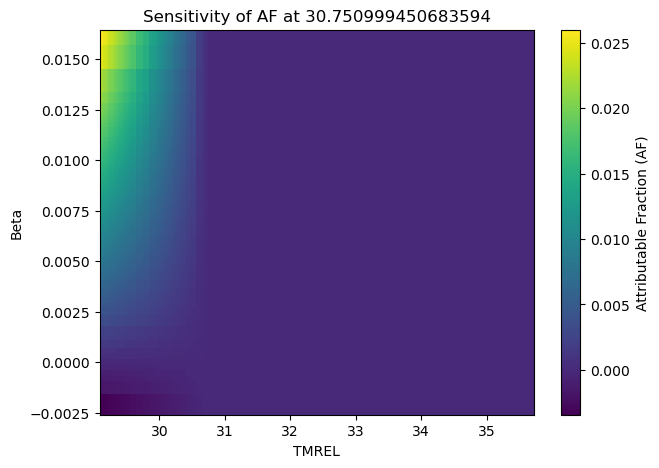

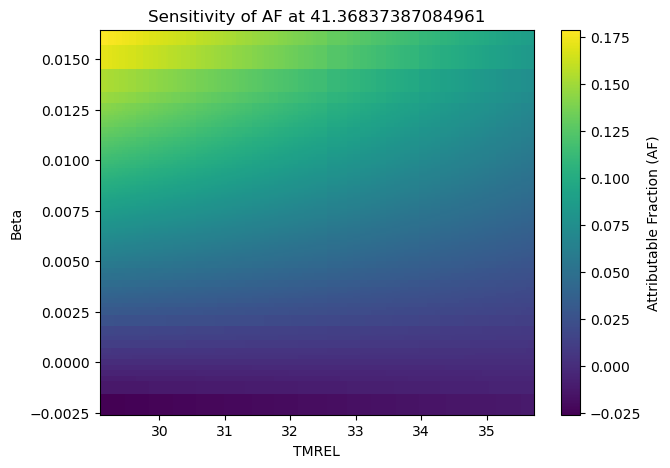

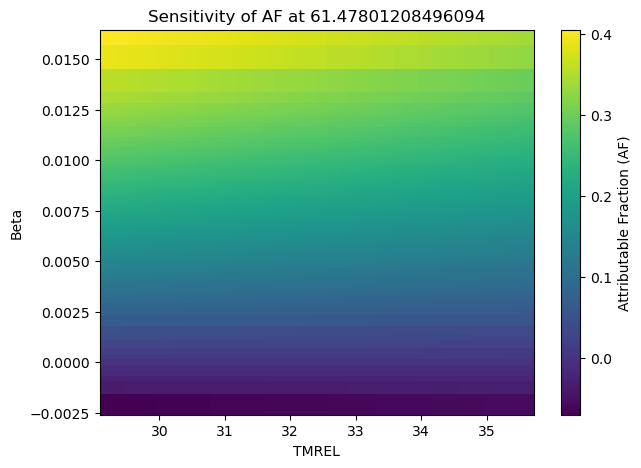

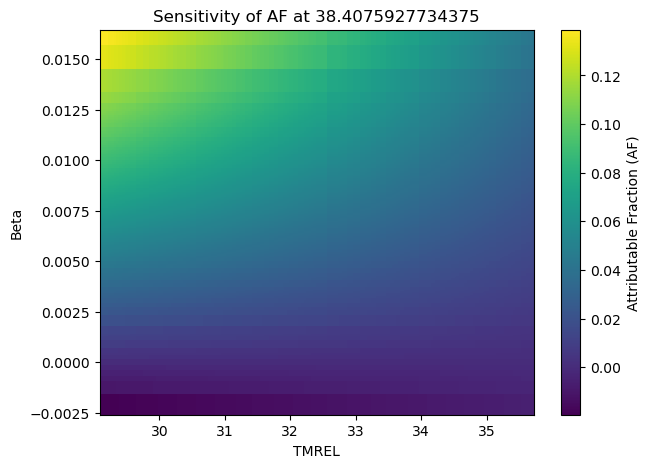

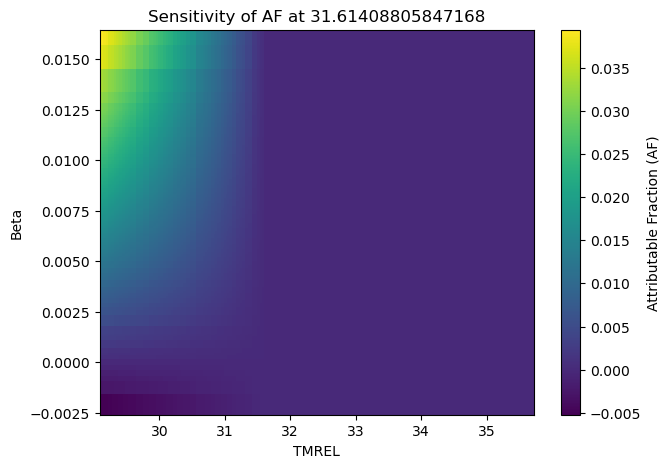

In [9]:
warnings.filterwarnings('ignore')

# === Scenario and path config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
model = "CESM2"
scenario = "G6-1.5K"

config = get_scenario_config(model, scenario)
years = config["years"]

O3_DIR = f"/glade/work/awells/air_quality/{model}/ozone/OSDMA8_BC/"
SAVE_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/global/"

dates = f"{years.start}-{years.stop - 1}"

# Load ozone data
o3_file = f"OSDMA8_BC_{model}_{scenario}_01_{dates}.nc"
o3_path = os.path.join(O3_DIR, o3_file)
o3 = xr.open_dataarray(o3_path).astype("float32")
o3 = o3.reindex_like(masks, method="nearest", tolerance=1e-9, fill_value=0)

del o3_file, o3_path

o3_year = o3.sel(year=2035)

del o3

random_lats = np.random.randint(1, 1801, 5)
random_lons = np.random.randint(1, 3601, 5)

for i in range(5):
    lat = random_lats[i]
    lon = random_lons[i]
    AF_grid = att_frac(o3_year.isel(lat=lat, lon=lon).values, TMREL_grid, beta_grid)

    plt.figure(figsize=(7, 5))
    c = plt.pcolormesh(TMREL_grid, beta_grid, AF_grid, shading="auto", cmap="viridis")
    plt.colorbar(c, label="Attributable Fraction (AF)")
    plt.xlabel("TMREL")
    plt.ylabel("Beta")
    plt.title(f"Sensitivity of AF at {o3_year.isel(lat=lat, lon=lon).values}")
    plt.show()

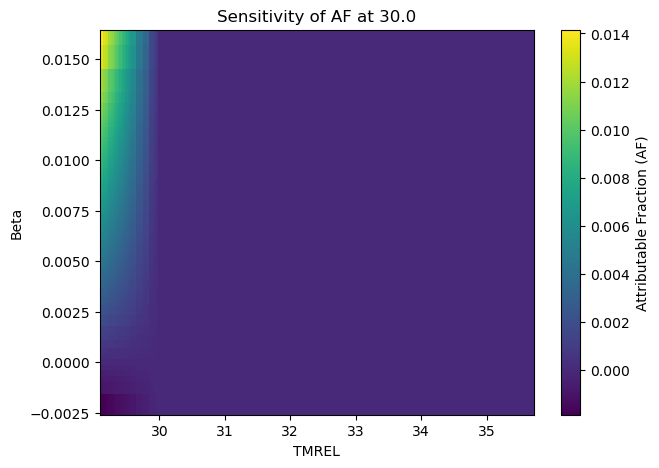

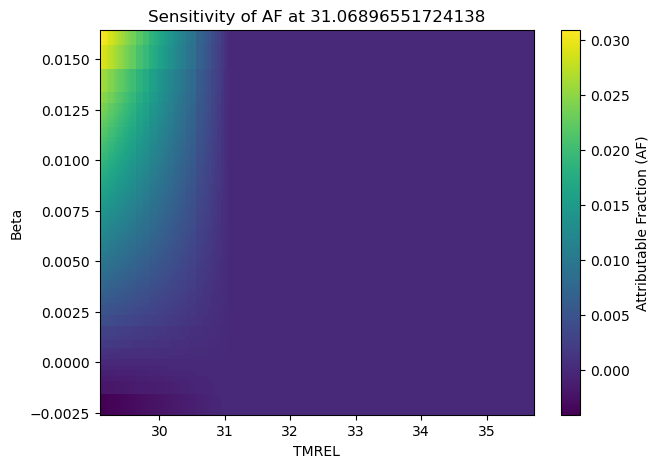

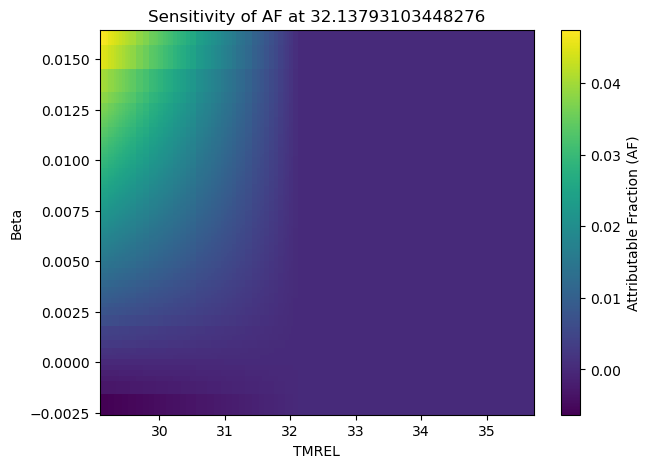

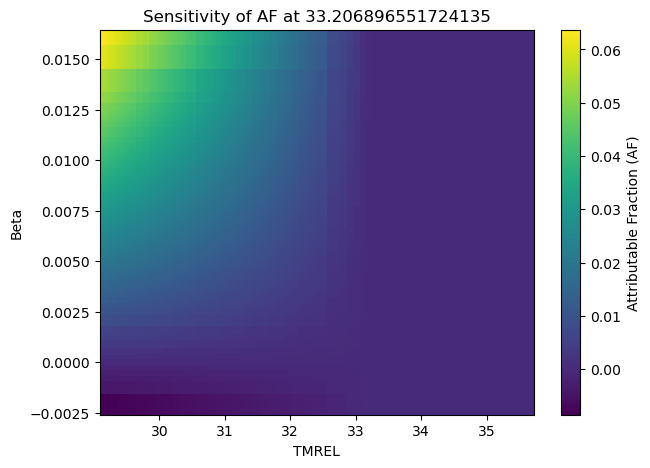

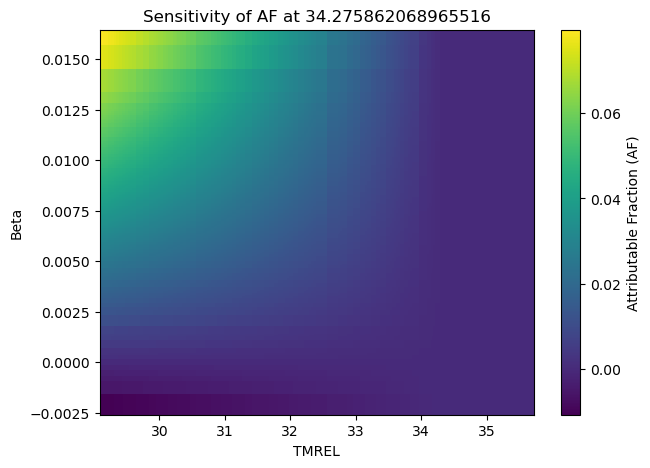

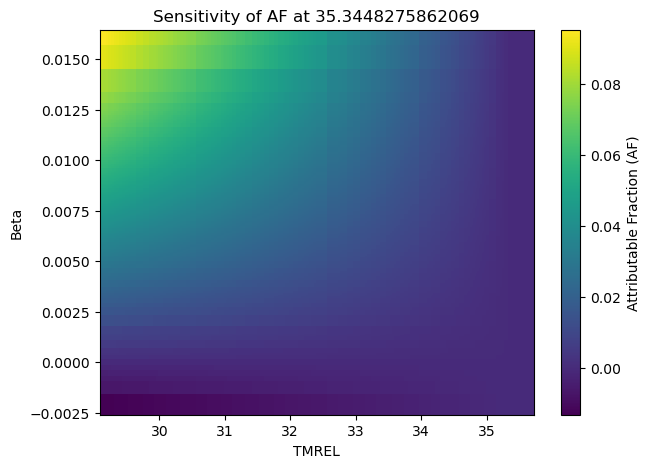

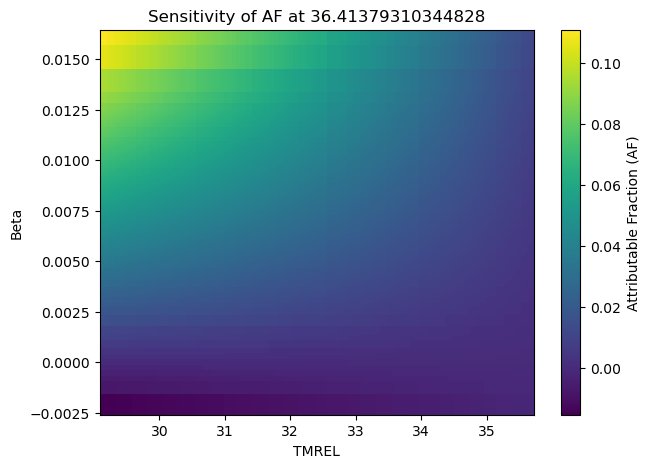

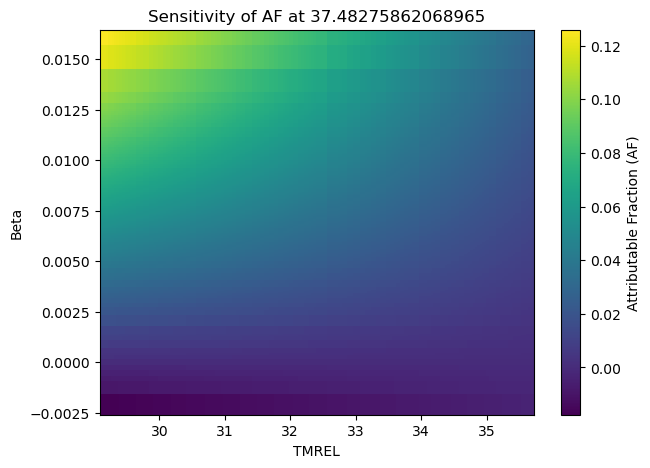

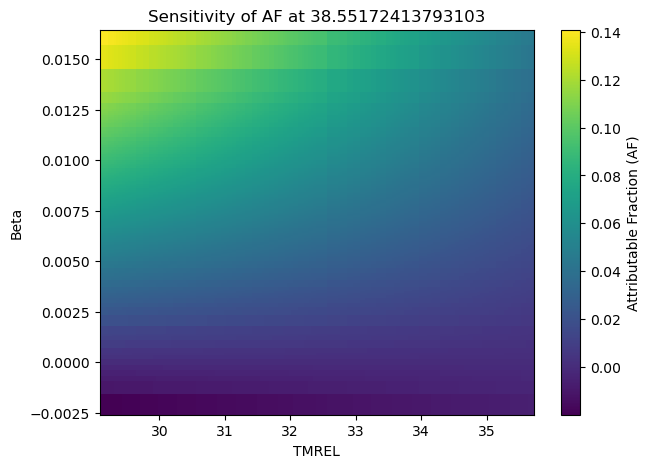

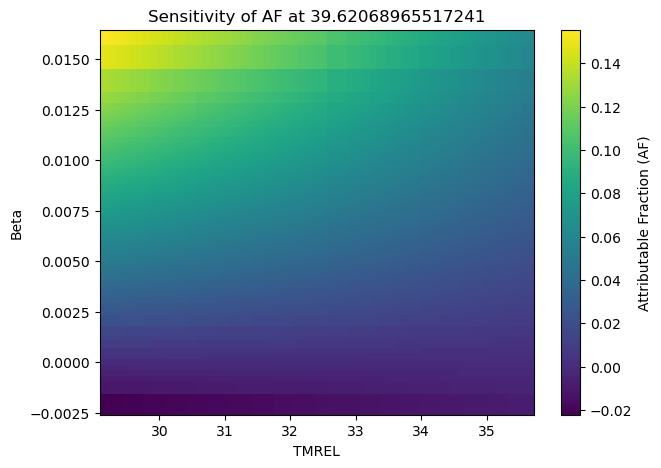

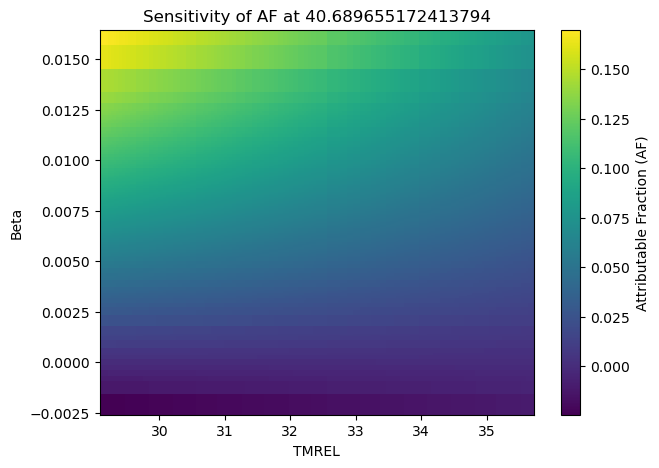

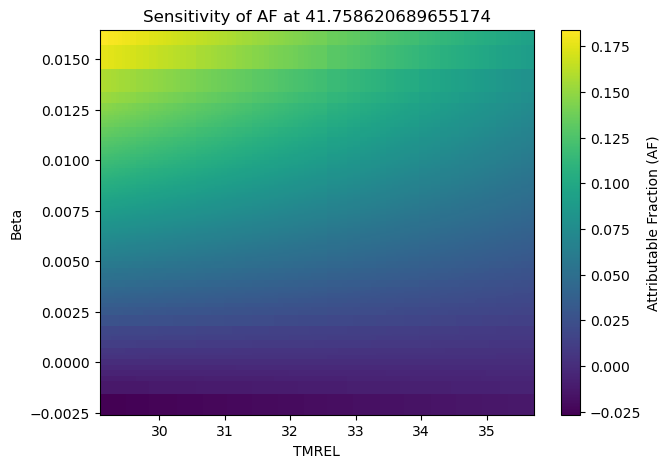

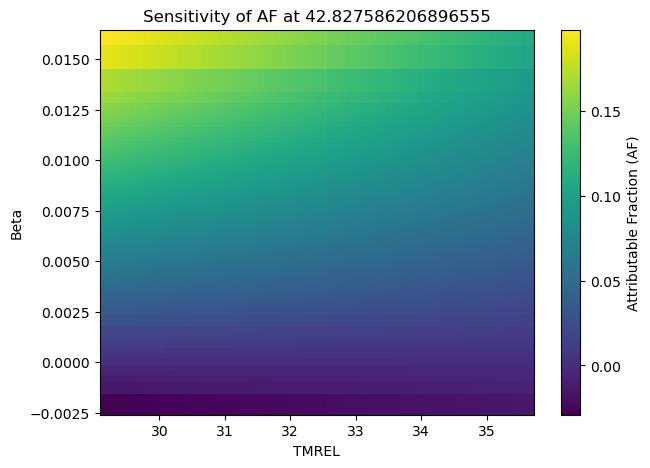

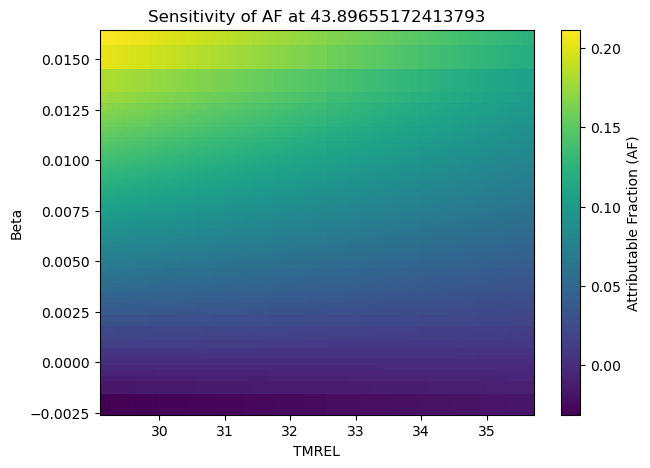

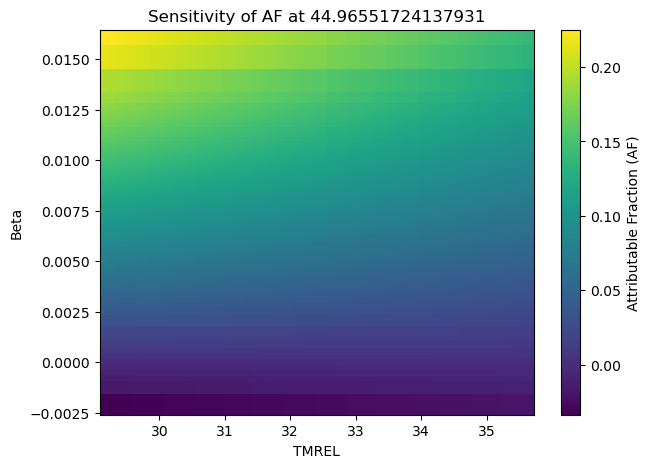

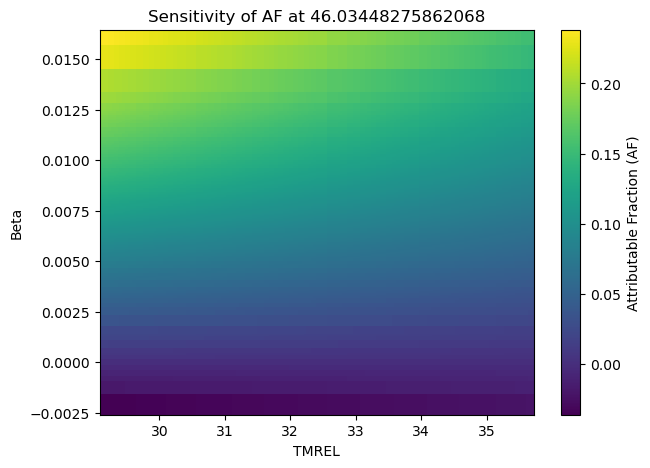

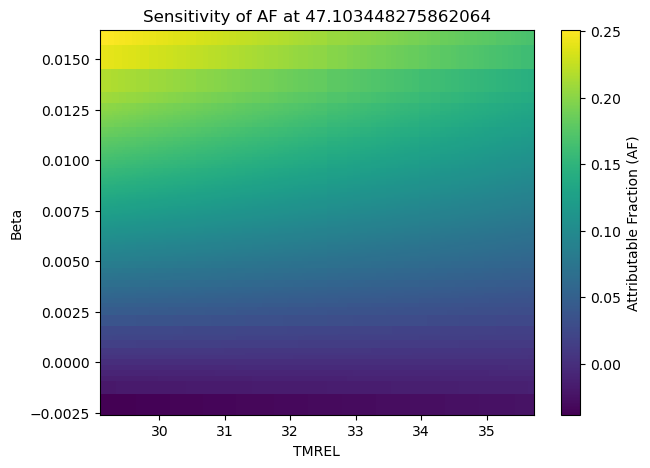

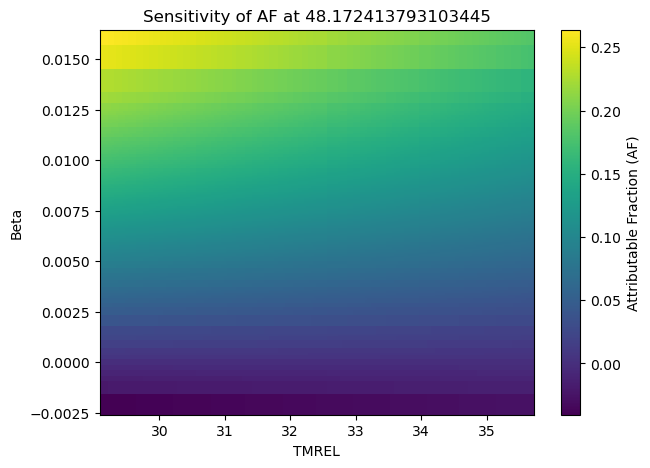

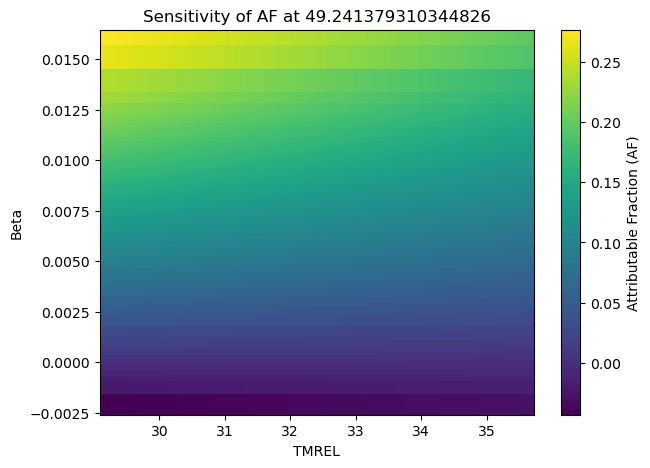

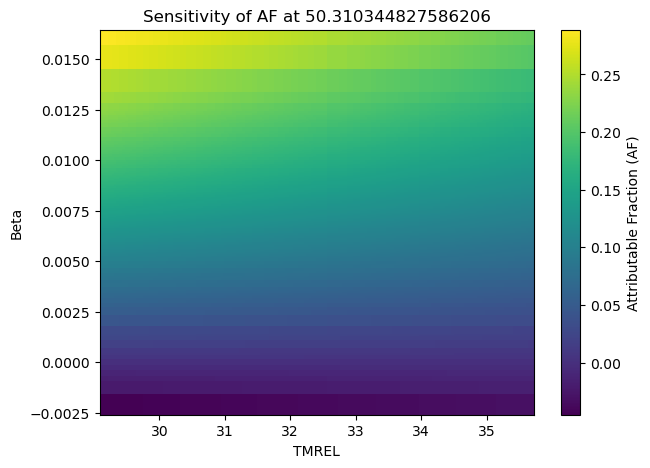

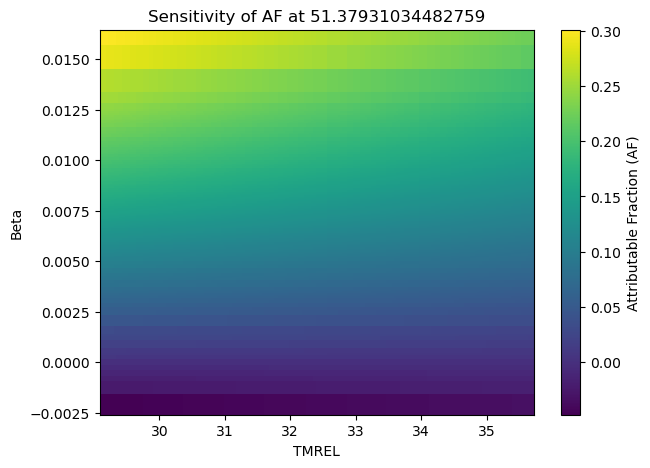

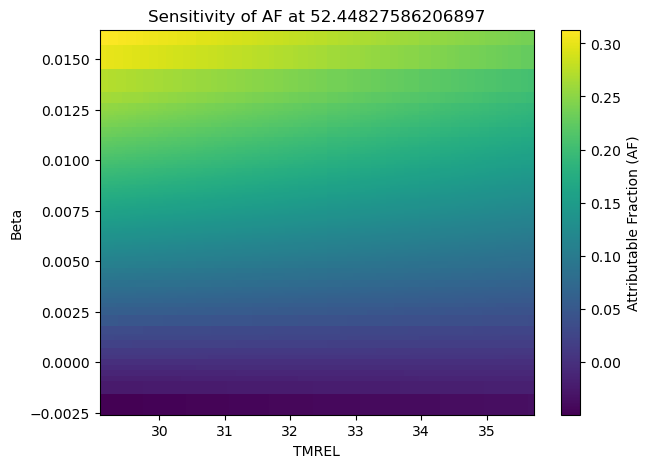

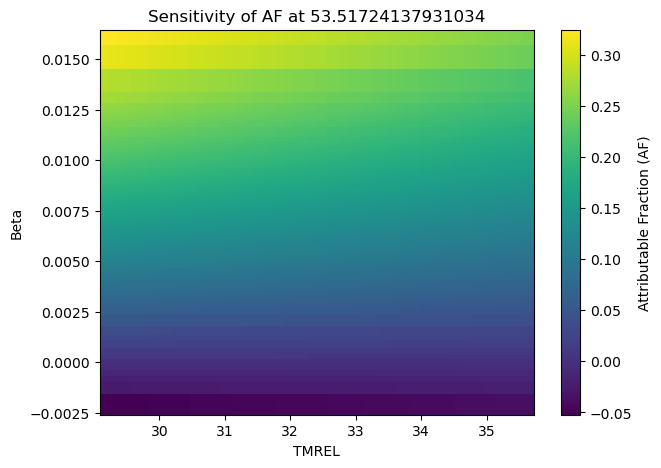

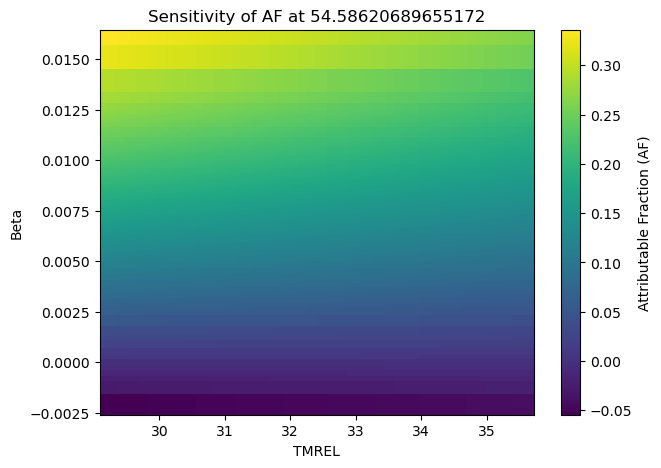

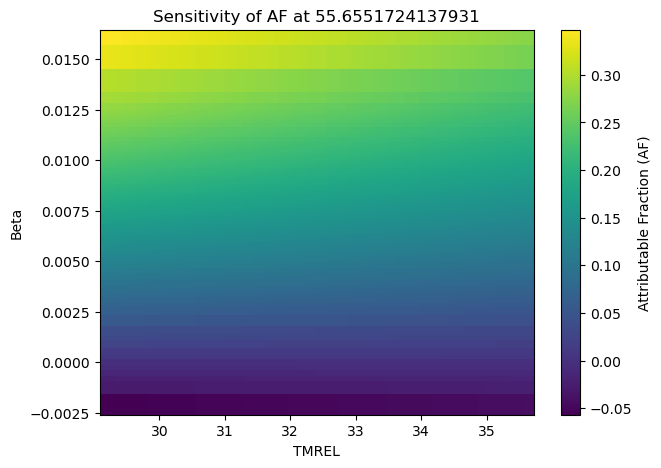

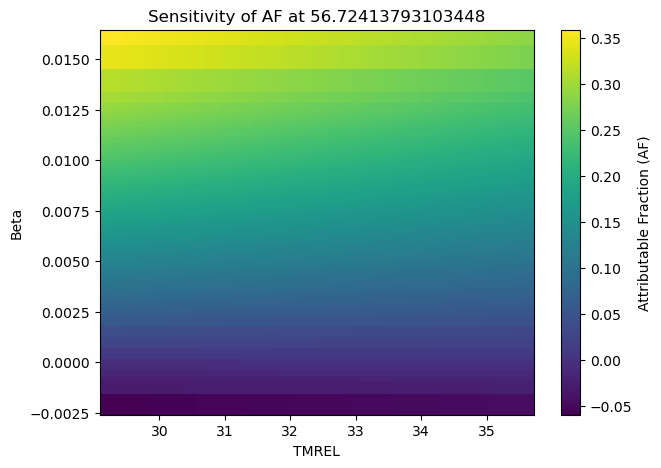

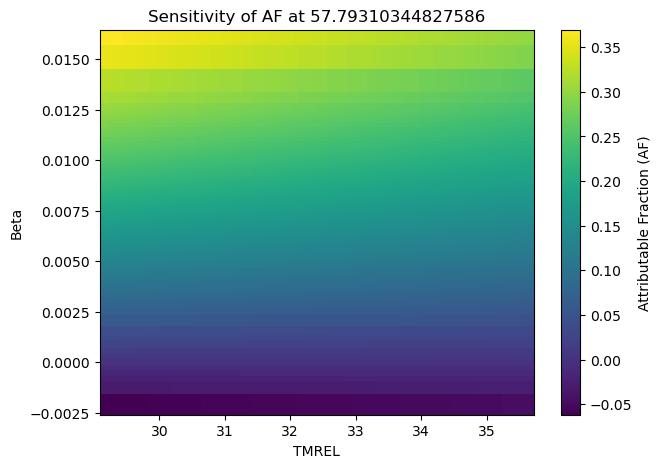

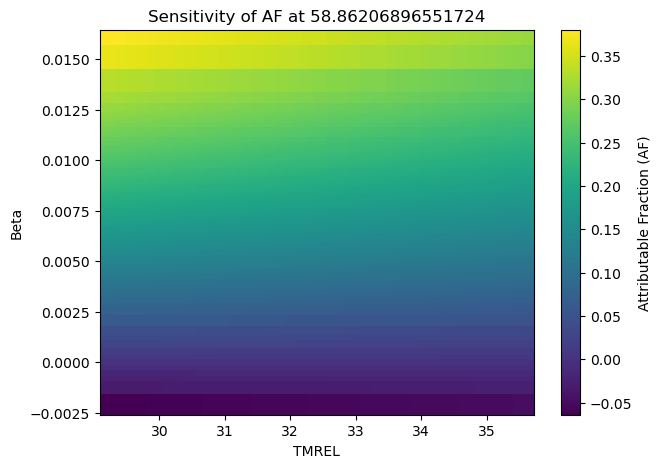

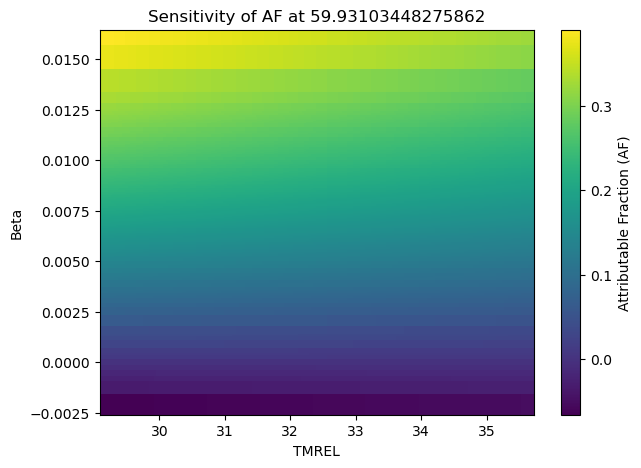

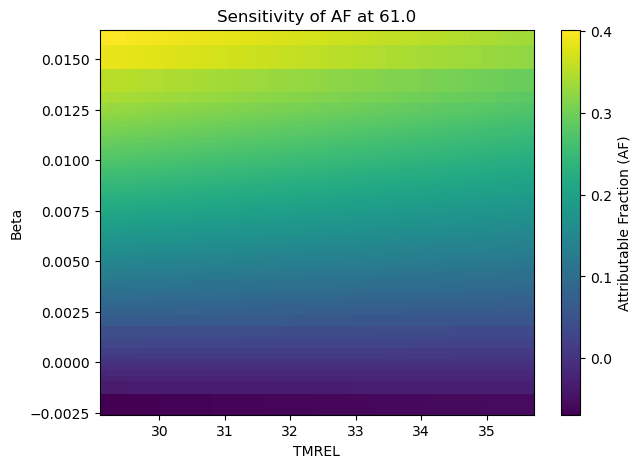

In [10]:
warnings.filterwarnings('ignore')

# === Scenario and path config ===
# Set to whatever scenario and model you want
# Function returns error if not recognised
model = "CESM2"
scenario = "G6-1.5K"

config = get_scenario_config(model, scenario)
years = config["years"]

O3_DIR = f"/glade/work/awells/air_quality/{model}/ozone/OSDMA8_BC/"
SAVE_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/global/"

dates = f"{years.start}-{years.stop - 1}"

# Load ozone data
o3_file = f"OSDMA8_BC_{model}_{scenario}_01_{dates}.nc"
o3_path = os.path.join(O3_DIR, o3_file)
o3 = xr.open_dataarray(o3_path).astype("float32")
o3 = o3.reindex_like(masks, method="nearest", tolerance=1e-9, fill_value=0)

del o3_file, o3_path

o3_year = o3.sel(year=2035)

del o3

ozone = np.linspace(30, 61, 30)

for i in ozone:
    AF_grid = att_frac(i, TMREL_grid, beta_grid)

    plt.figure(figsize=(7, 5))
    c = plt.pcolormesh(TMREL_grid, beta_grid, AF_grid, cmap="viridis")
    plt.colorbar(c, label="Attributable Fraction (AF)")
    plt.xlabel("TMREL")
    plt.ylabel("Beta")
    plt.title(f"Sensitivity of AF at {i}")
    plt.show()